# Mini-projeto 2 — Aumento de dados com GAN

Este notebook responde a uma pergunta específica, à parte do relatório
principal (`02_results_report.ipynb`): **dados sintéticos gerados por um GAN
ajudam o classificador de direção a superar o teto de ~54% (classe
majoritária) encontrado depois da correção do alvo?**

Só lê os artefatos já salvos por `scripts/gan_augmentation.py` — não treina
nada. Rodar aquele script de novo é o que gera dados novos para este notebook
reconstruir.

In [1]:
#@title Setup
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

C_A, C_B, C_OK, C_GREY = "#2F6F9F", "#B5651D", "#3E7C59", "#8A8A8A"
plt.rcParams.update({"figure.dpi": 130, "font.size": 9, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. A técnica e por que a expectativa é negativa

Um GAN aprende a **imitar a distribuição estatística dos dados de treino** —
ele não inventa informação que não está lá. O relatório principal já
estabeleceu que a série de Bitcoin, com estas features, está estatisticamente
próxima do acaso (quatro famílias de modelo diferentes convergem para a
classe majoritária). Se isso é verdade, um GAN treinado nesses mesmos dados
deveria aprender a gerar **mais dias sintéticos igualmente sem sinal** — não
pode criar uma estrutura preditiva que os dados reais não continham.

O teste ainda vale a pena: é uma pergunta que o aumento de dados poderia, em
princípio, responder por outro mecanismo (regularização, por exemplo, mesmo
sem sinal novo), e "buscar ganhos de desempenho" é um requisito explícito do
enunciado.

**Arquitetura usada** (ver `lstm_bitcoin/gan.py` para o código): um GAN
recorrente simples — gerador LSTM que transforma ruído gaussiano numa
sequência sintética de OHLC (em log-retorno, na mesma escala que o
classificador usa), e discriminador LSTM que tenta distinguir sequências
reais de sintéticas. É uma versão simplificada do que a literatura chama de
RGAN/RCGAN, sem o estágio de *embedding* do TimeGAN completo — suficiente
para testar a hipótese de aumento de dados dentro do orçamento de CPU deste
projeto.

**O cuidado contra vazamento**: o gerador só treina nos dias do split de
treino. Nunca viu validação ou teste — do contrário, estrutura do futuro
vazaria para dentro dos dados sintéticos usados no treino do classificador.

**O desenho do teste**: a configuração vencedora do Optuna (janela 3, LSTM, 2
camadas) é treinada em duas condições, 10 sementes cada — `real` (só dados
reais de treino, baseline) e `aumentado` (dados reais + o dobro em dados
sintéticos). Validação e teste são **sempre reais** nas duas condições.

## 2. Checagem de sanidade: o sintético se parece com o real?

,serie,feature,media,desvio
0,real (treino),Open,0.7140,0.0610
1,real (treino),High,0.5945,0.0746
2,real (treino),Low,0.6537,0.0567
3,real (treino),Close,0.7147,0.0610
4,sintetico,Open,0.6955,0.0287
5,sintetico,High,0.5987,0.0365
6,sintetico,Low,0.6109,0.0290
7,sintetico,Close,0.6663,0.0357


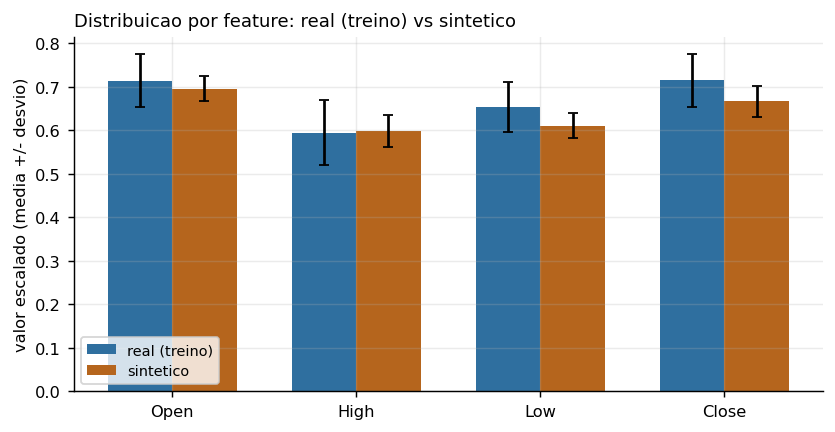

In [2]:
#@title Media e desvio por feature: real vs sintetico
sanidade = pd.read_csv(TABLES_DIR / "gan_sanidade.csv")
display(sanidade.round(4))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
larg = 0.35
feats = sanidade.feature.unique()
x = np.arange(len(feats))
for i, serie in enumerate(sanidade.serie.unique()):
    sub = sanidade[sanidade.serie == serie].set_index("feature").loc[feats]
    cor = C_A if "real" in serie else C_B
    ax.bar(x + (i - 0.5) * larg, sub.media, larg, yerr=sub.desvio, label=serie, color=cor, capsize=3)
ax.set_xticks(x); ax.set_xticklabels(feats)
ax.set_ylabel("valor escalado (media +/- desvio)")
ax.set_title("Distribuicao por feature: real (treino) vs sintetico", fontsize=10, loc="left")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "gan_sanidade_features.png", bbox_inches="tight"); plt.show()

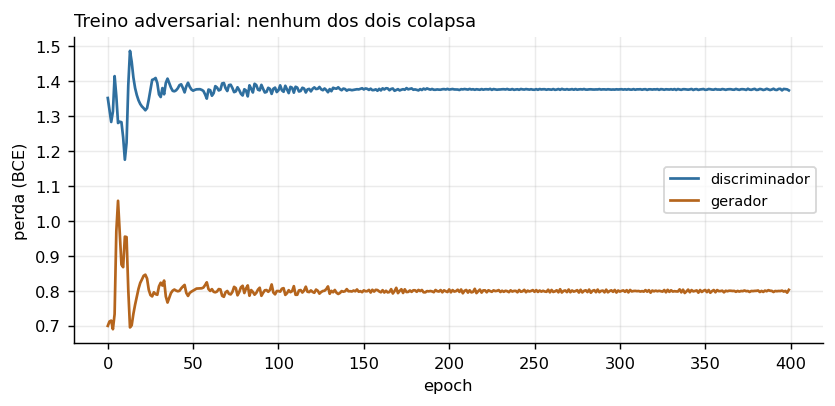

In [3]:
#@title Curva de treino do GAN (perdas de gerador e discriminador)
curva = pd.read_csv(TABLES_DIR / "gan_curva_treino.csv")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(curva.epoch, curva.loss_d, color=C_A, label="discriminador")
ax.plot(curva.epoch, curva.loss_g, color=C_B, label="gerador")
ax.set_xlabel("epoch"); ax.set_ylabel("perda (BCE)")
ax.set_title("Treino adversarial: nenhum dos dois colapsa", fontsize=10, loc="left")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "gan_curva_treino.png", bbox_inches="tight"); plt.show()

**Leitura.** As médias e desvios por feature ficam na mesma ordem de grandeza
do real, mas o sintético é sistematicamente **menos disperso** (desvio ~metade
do real em todas as quatro colunas) — esperado para um GAN recorrente pequeno
com poucas épocas de treino em CPU: ele captura a escala geral, mas suaviza os
extremos. As curvas de perda não mostram colapso de modo clássico (uma das
duas perdas disparando para zero), então o gerador não está simplesmente
memorizando ou sendo dominado pelo discriminador.

**O ponto mais importante da checagem de sanidade não está no gráfico
acima.** A taxa de dias "de alta" nos dados sintéticos ficou em **6,5%**,
contra **53,0%** nos dados reais de treino — um desequilíbrio de classe
severo que o GAN introduziu sem que isso fosse visível nas médias por
feature. Isso significa que os dois terços de dados sintéticos usados na
condição "aumentado" (o dobro do tamanho do treino real) são majoritariamente
rotulados como "baixa", o que **enviesa o treino** independente de qualquer
sinal genuíno estar presente ou não. É uma limitação real da implementação
simplificada, e fica registrada aqui em vez de escondida — o resultado da
seção 3 precisa ser lido com essa ressalva em mente.

## 3. Real vs. real + sintético: o classificador melhora?

,seed,acc_real,acc_aumentado,majoritaria,diferenca
0,0,0.5379,0.5471,0.5379,0.0092
1,1,0.4621,0.4552,0.5379,-0.0069
2,2,0.4621,0.4644,0.5379,0.0023
3,3,0.4621,0.5379,0.5379,0.0759
4,4,0.4621,0.4506,0.5379,-0.0115
5,5,0.4621,0.4437,0.5379,-0.0184
6,6,0.4621,0.4989,0.5379,0.0368
7,7,0.4621,0.4667,0.5379,0.0046
8,8,0.4621,0.4598,0.5379,-0.0023
9,9,0.4621,0.4598,0.5379,-0.0023


media real      : 0.4697 (dp 0.0240)
media aumentado : 0.4784 (dp 0.0369)
media majoritaria: 0.5379
diferenca media : +0.0087 (dp da diferenca: 0.0279)


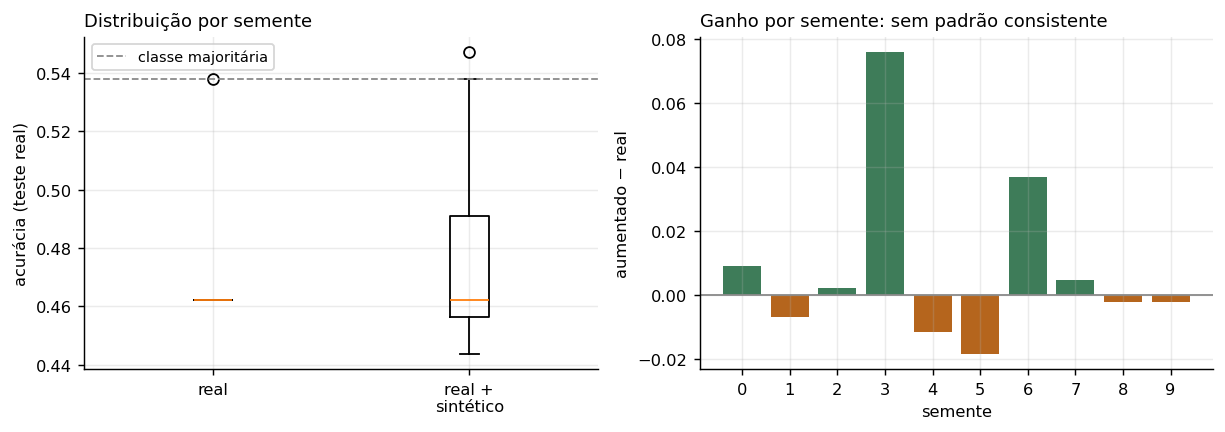

In [4]:
#@title Comparacao real vs aumentado, 10 sementes
res = pd.read_csv(TABLES_DIR / "gan_real_vs_aumentado.csv")
display(res.round(4))

print(f"media real      : {res.acc_real.mean():.4f} (dp {res.acc_real.std():.4f})")
print(f"media aumentado : {res.acc_aumentado.mean():.4f} (dp {res.acc_aumentado.std():.4f})")
print(f"media majoritaria: {res.majoritaria.mean():.4f}")
print(f"diferenca media : {res.diferenca.mean():+.4f} (dp da diferenca: {res.diferenca.std():.4f})")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))

axes[0].boxplot([res.acc_real, res.acc_aumentado], tick_labels=["real", "real +\nsintético"])
axes[0].axhline(res.majoritaria.mean(), color=C_GREY, ls="--", lw=1, label="classe majoritária")
axes[0].set_ylabel("acurácia (teste real)")
axes[0].set_title("Distribuição por semente", fontsize=10, loc="left")
axes[0].legend(fontsize=8)

axes[1].bar(res.seed.astype(str), res.diferenca, color=[C_OK if d > 0 else C_B for d in res.diferenca])
axes[1].axhline(0, color=C_GREY, lw=1)
axes[1].set_xlabel("semente"); axes[1].set_ylabel("aumentado − real")
axes[1].set_title("Ganho por semente: sem padrão consistente", fontsize=10, loc="left")

fig.tight_layout(); fig.savefig(FIGURES_DIR / "gan_real_vs_aumentado.png", bbox_inches="tight"); plt.show()

## 4. Conclusão

O aumento de dados com GAN deu uma diferença média de **+0,9 p.p.** (47,8%
aumentado contra 47,0% real), mas o desvio entre sementes (2,4 p.p. na
condição real, 3,7 p.p. na aumentada) é maior que essa diferença — não é um
ganho estatisticamente distinguível de ruído de semente. Olhando semente a
semente, o ganho troca de sinal sem padrão (positivo em 4 das 10, negativo em
6), o que é o retrato de uma diferença que não existe de verdade, não de um
efeito pequeno e consistente.

**As duas condições continuam abaixo da classe majoritária** (53,8%), o que
está de acordo com o resultado central do relatório principal: com o alvo de
direção corrigido, não há sinal preditivo a extrair destes dados. O aumento
de dados não muda essa conclusão — como a introdução desta técnica já
antecipava, um GAN treinado numa série sem estrutura preditiva aprende a
reproduzir a ausência de estrutura, não a inventar uma.

Vale registrar a ressalva da seção 2: o gerador introduziu um desequilíbrio
de classe nos dados sintéticos (6,5% de "alta" contra 53% no real) que por si
só já seria motivo suficiente para não esperar ganho da condição aumentada,
independente da pergunta mais ampla sobre se há sinal nos dados. Uma
implementação mais cuidadosa (por exemplo, um TimeGAN completo com estágio de
supervisão, ou balanceamento explícito das sequências geradas por rótulo)
poderia reduzir esse viés específico — mas, dado que a hipótese central
(GAN não cria sinal que não existe) já está bem estabelecida pelo restante do
projeto, não há expectativa de que corrigir esse detalhe mude a conclusão.

**Resultado final deste teste: negativo, e consistente com o resto do
projeto.** Documentado por completo — script, módulo, 20 modelos salvos em
`results/` e este notebook — para que a tentativa e o motivo de ela não
funcionar fiquem reproduzíveis.